In [379]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [380]:
df = pd.read_csv("data/first_period/fiuna.csv")

In [381]:
df['timestamp'] = pd.to_datetime(df.timestamp)
#df.set_index(['datetime'], drop=True,inplace = True)

In [382]:
df.set_index(['timestamp'], drop=True,inplace = True)

In [383]:
def remove_outliers(df_in, col_name):
  q1,q3 = np.percentile(df_in.loc[:,col_name],[25,75])
  iqr = q3 - q1
  upper_limit = q3 + 1.5 * iqr
  lower_limit = q1 - 1.5 * iqr
  df_in.loc[(df_in[col_name] < lower_limit) | (df_in[col_name] > upper_limit), col_name] = np.nan
  return df_in


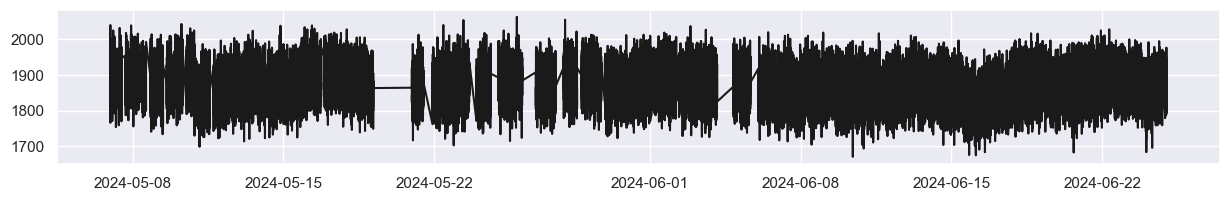

In [384]:
plt.figure(figsize=(15, 2))
#plt.plot(df2.index,df2['muons'], color = 'red')
plt.plot(df.index,df['muons'], color = 'k')
#plt.plot(df.index, df['25'])

In [385]:
df2=df

In [386]:
df2 = df2.apply(pd.to_numeric, errors='coerce')
df2 = df2.resample('h').mean()

In [387]:
df2

,muons,lab_temp,external_temp,external_pressure
timestamp,,,,
2024-05-06 23:00:00,1887.983333,22.926667,29.275000,990.241667
2024-05-07 00:00:00,1896.433333,23.083333,28.666667,990.766667
2024-05-07 01:00:00,1887.716667,23.090000,27.791667,991.033333
2024-05-07 02:00:00,1894.150000,23.213333,29.200000,991.116667
2024-05-07 03:00:00,1884.816667,22.920000,29.200000,991.241667
...,...,...,...,...
2024-06-24 19:00:00,NaN,NaN,NaN,NaN
2024-06-24 20:00:00,NaN,NaN,NaN,NaN
2024-06-24 21:00:00,1880.083333,17.200000,17.191667,1001.083333


In [388]:
flag2 = np.logical_and(df2.index >= '2024-05-07 00:00:00', df2.index <= '2024-05-17 23:59:00')
df3 = df2[flag2]

In [389]:
df1 = df.copy()

In [390]:
df4 = pd.read_csv('data/first_period/profileweather_teff.csv')

In [391]:
df4['timestamp'] = pd.to_datetime(df4.timestamp)
df4.set_index(['timestamp'], drop=True,inplace = True)
df4

,Ps,Ts,TMP_MSS
timestamp,,,
2024-05-06 00:00:00,998.265817,297.063735,263.162002
2024-05-06 01:00:00,998.481085,297.022934,263.165953
2024-05-06 02:00:00,998.696353,296.982134,263.169903
2024-05-06 03:00:00,998.911621,296.941333,263.173853
2024-05-06 04:00:00,998.394688,297.166970,263.100836
...,...,...,...
2024-06-24 17:00:00,1006.131962,288.505471,258.638804
2024-06-24 18:00:00,1006.082687,288.462057,258.611486
2024-06-24 19:00:00,1005.936568,287.890748,258.610787


In [392]:
df_merged = pd.merge(df3, df4, on='timestamp', how='outer')

# Ordenar por índice de tiempo para asegurar que las filas estén en orden cronológico
df_merged.sort_values('timestamp', inplace=True)

In [393]:
flag7 = np.logical_and(df_merged.index >= '2024-05-07 00:00:00', df_merged.index <= '2024-05-17 23:59:00')
df_merged = df_merged[flag7]
df_merged

,muons,lab_temp,external_temp,external_pressure,Ps,Ts,TMP_MSS
timestamp,,,,,,,
2024-05-07 00:00:00,1896.433333,23.083333,28.666667,990.766667,994.339032,302.220522,263.617805
2024-05-07 01:00:00,1887.716667,23.090000,27.791667,991.033333,995.337349,301.924119,263.560956
2024-05-07 02:00:00,1894.150000,23.213333,29.200000,991.116667,996.335667,301.627716,263.504107
2024-05-07 03:00:00,1884.816667,22.920000,29.200000,991.241667,997.333984,301.331312,263.447258
2024-05-07 04:00:00,1885.983333,22.390000,28.516667,991.108333,996.418878,300.804519,263.353770
...,...,...,...,...,...,...,...
2024-05-17 19:00:00,1892.466667,16.146667,14.358333,1000.200000,1006.232426,286.692983,258.885872
2024-05-17 20:00:00,NaN,NaN,NaN,NaN,1006.075952,286.670518,258.871927
2024-05-17 21:00:00,NaN,NaN,NaN,NaN,1005.919479,286.648054,258.857983


df_merged = pd.merge(df1, df2, on='datetime', how='outer')

# Ordenar por índice de tiempo para asegurar que las filas estén en orden cronológico
df_merged.sort_values('datetime', inplace=True)

In [394]:
df6 = df_merged.copy()

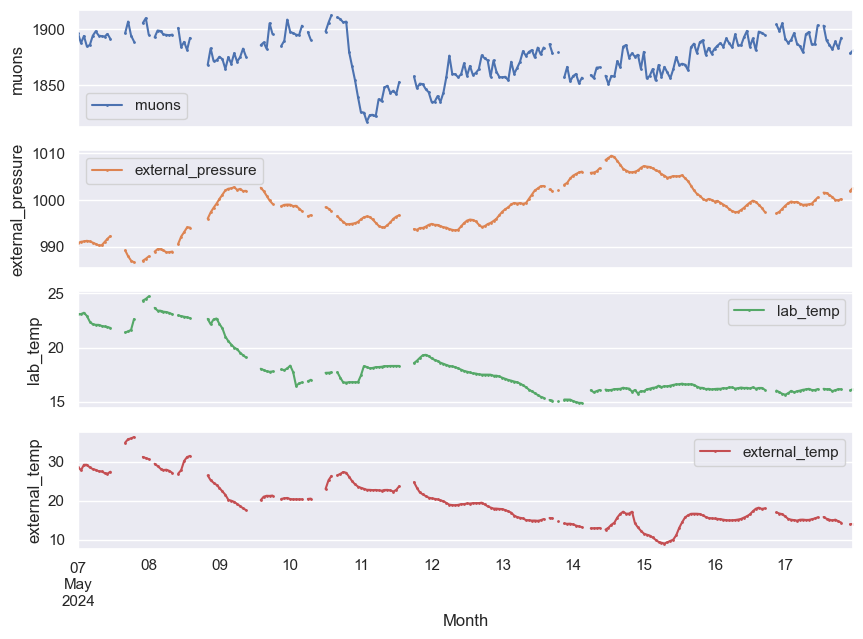

In [395]:
var = ['muons', 'external_pressure','lab_temp', 'external_temp']
       # 'external_pressure']
       #,'Pressup','Tempsup', 'TMP_MSS']

axes = df_merged[var].plot(marker='.', markersize=2 , figsize=(10, 7), subplots=True)
for ax,v in zip(axes,var):
    ax.set_ylabel(v)
    ax.set_xlabel('Month')

In [396]:
flag2 = np.logical_and(df_merged.index >= '2024-05-17 00:00:00', df_merged.index <= '2024-05-31 23:59:00')
df7 = df_merged[flag2]

In [397]:
P0=df_merged['external_pressure'].dropna().mean()
Im=df_merged['muons'].dropna().mean()

In [398]:
df_merged['muon2'] = df['muons'] - Im

In [399]:
df_merged['ln_IoIm']=  (df_merged['muons'] - df_merged['muons'].mean())/df_merged['muons'] *100
df_merged['dP']=df_merged['external_pressure']-P0

In [400]:
df_merged['ln_IoIm']=  np.log((df_merged['muons'])/(Im))*100
df_merged['dP']=df_merged['external_pressure']-P0

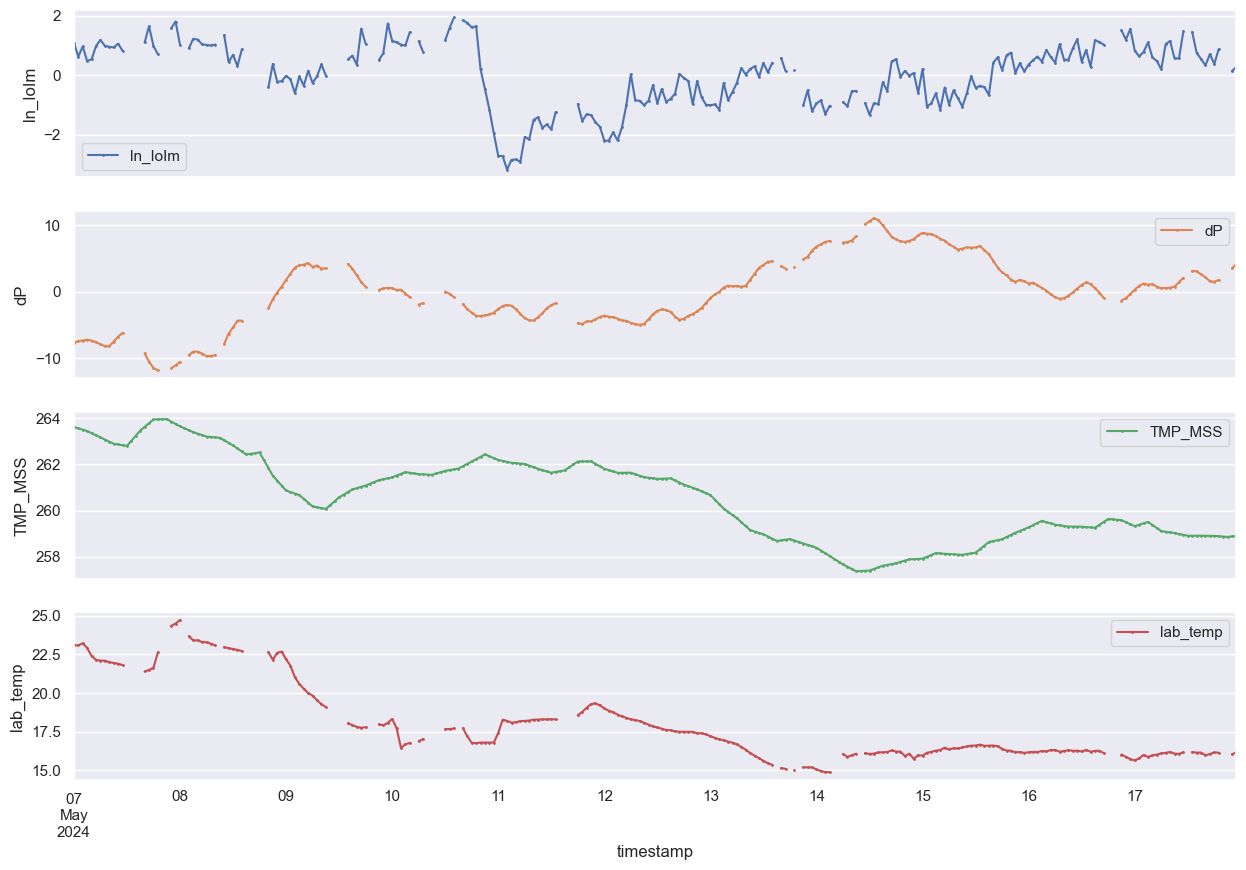

In [401]:
var=['ln_IoIm','dP','TMP_MSS','lab_temp']
axes = df_merged[var].plot(marker='.', markersize=2 , linestyle='-', figsize=(15, 10), subplots=True)
for ax,v in zip(axes,var):
    ax.set_ylabel(v)

In [402]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

In [403]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Supongamos que df_merged es tu DataFrame original

# Verificar la cantidad de NaNs en el DataFrame
print("Valores NaN antes del procesamiento:")
print(df_merged.isna().sum())

# Crear un imputador que reemplace los NaN con la media de la columna
imputer = SimpleImputer(strategy='mean')

# Imputar valores faltantes en las columnas 'V', 'delta' y 'V_media'
df_merged[['ln_IoIm','dP']] = imputer.fit_transform(df_merged[['ln_IoIm','dP']])

# Verificar que ya no hay valores NaN
print("Valores NaN después del procesamiento:")
print(df_merged.isna().sum())

Valores NaN antes del procesamiento:
muons                41
lab_temp             41
external_temp        41
external_pressure    41
Ps                    0
Ts                    0
TMP_MSS               0
muon2                41
ln_IoIm              41
dP                   41
dtype: int64
Valores NaN después del procesamiento:
muons                41
lab_temp             41
external_temp        41
external_pressure    41
Ps                    0
Ts                    0
TMP_MSS               0
muon2                41
ln_IoIm               0
dP                    0
dtype: int64


In [404]:
X = (df_merged[['dP']].values)
y = df_merged['ln_IoIm'].values

# Ahora puedes ajustar tu modelo
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [405]:
X = pd.to_numeric(df_merged['dP'],errors= 'coerce')
y = pd.to_numeric(df_merged['ln_IoIm'],errors= 'coerce')

In [406]:
result = np.correlate(X,y)

In [407]:
pp = result.mean()
pp

-215.78826304186944

In [408]:
def linear(x,a,b):
    return a + b*x

In [409]:
from scipy.optimize import curve_fit

In [410]:
popt, pcov  = curve_fit(linear,X,y)

In [411]:
a,b = popt
print(a,b)

-0.0056728330114408365 -0.03680228467588709


In [412]:
coef = model.coef_[0]
intercept = model.intercept_
print(f'Coeficiente: {coef}')
print(f'Intercepto: {intercept}')

Coeficiente: -0.036802284650971816
Intercepto: -0.005672834998836733


In [413]:
beta=model.coef_[0]

In [414]:
df_merged['IoPC2'] =  df_merged['ln_IoIm'] *beta * df_merged['dP']

In [415]:
df_merged['IoPC'] =  df_merged['muons']* np.exp(- 0.01*   beta * (df_merged['dP'].values))

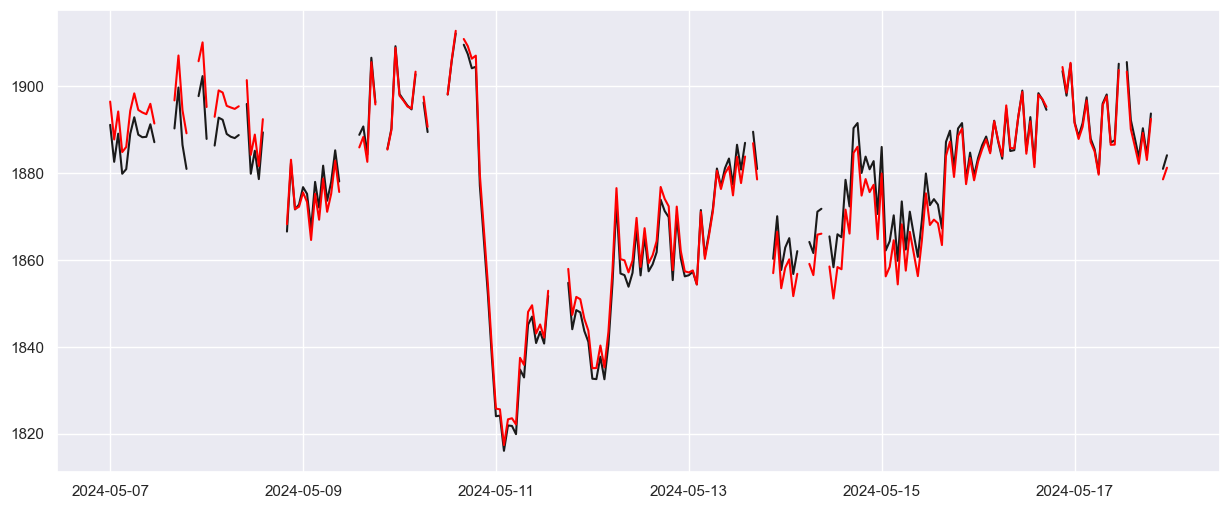

In [416]:
plt.figure(figsize=(15, 6))
#plt.plot(df_merged.index,df_merged['IoPC'], color = 'green')#
#plt.plot(df_merged.index,df_merged['25'], color = 'red')
#plt.plot(df_merged.index,df_merged['IoTPC'], color = 'blue')
plt.plot(df_merged.index,df_merged['IoPC'], color = 'k')
plt.plot(df_merged.index,df_merged['muons'], color = 'red')
#plt.plot(df_merged.index,df_merged['teste'], color = 'yellow')

In [419]:
df_merged.head()

,muons,lab_temp,external_temp,external_pressure,Ps,Ts,TMP_MSS,muon2,ln_IoIm,dP,IoPC2,IoPC
timestamp,,,,,,,,,,,,
2024-05-07 00:00:00,1896.433333,23.083333,28.666667,990.766667,994.339032,302.220522,263.617805,57.00707,1.083685,-7.684215,0.306462,1891.077859
2024-05-07 01:00:00,1887.716667,23.090000,27.791667,991.033333,995.337349,301.924119,263.560956,19.00707,0.622990,-7.417548,0.170066,1882.570553
2024-05-07 02:00:00,1894.150000,23.213333,29.200000,991.116667,996.335667,301.627716,263.504107,-45.99293,0.963211,-7.334215,0.259986,1889.044282
2024-05-07 03:00:00,1884.816667,22.920000,29.200000,991.241667,997.333984,301.331312,263.447258,-12.99293,0.469248,-7.209215,0.124499,1879.822582
2024-05-07 04:00:00,1885.983333,22.390000,28.516667,991.108333,996.418878,300.804519,263.353770,-6.99293,0.531127,-7.342548,0.143522,1880.893861


In [420]:
import scipy
import seaborn as sns

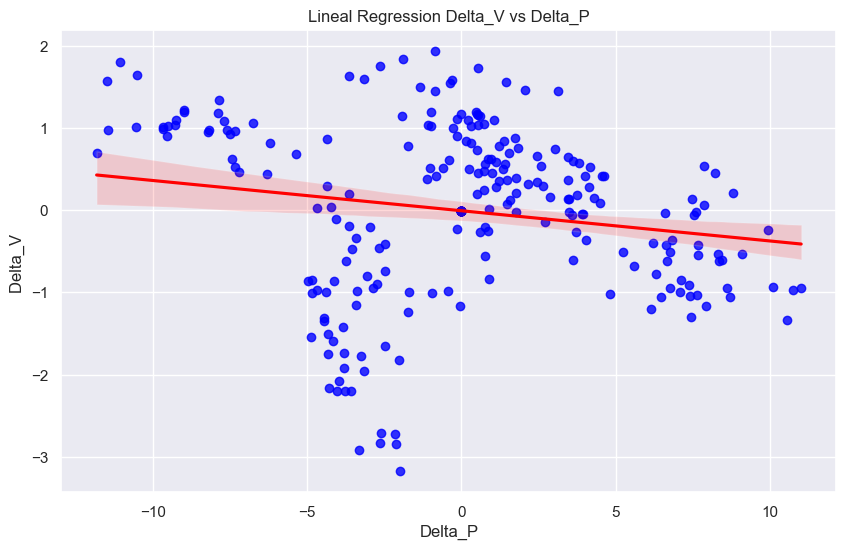

In [421]:
sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))
p=sns.regplot(x='dP', y='ln_IoIm', data=df_merged, scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel('Delta_P')
plt.ylabel('Delta_V ')
plt.title('Lineal Regression Delta_V vs Delta_P')
#slope, intercept, r, p, sterr = scipy.stats.linregress(x=p.get_lines()[0].get_xdata(),y=p.get_lines()[0].get_ydata())

#plt.text(2, 95, 'y = ' + str(round(intercept,3)) + ' + ' + str(round(slope,3)) + 'x')
plt.show()

In [422]:
T0=df_merged['TMP_MSS'].dropna().mean()
Im2=df_merged['IoPC'].dropna().mean()

In [423]:
df_merged['ln_IoIm2']=  np.log(df_merged['IoPC']/(Im2))*100
df_merged['dT']=df_merged['TMP_MSS']-T0

In [424]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Supongamos que df_merged es tu DataFrame original

# Verificar la cantidad de NaNs en el DataFrame
print("Valores NaN antes del procesamiento:")
print(df_merged.isna().sum())

# Crear un imputador que reemplace los NaN con la media de la columna
imputer = SimpleImputer(strategy='mean')

# Imputar valores faltantes en las columnas 'V', 'delta' y 'V_media'
df_merged[['ln_IoIm2','dT']] = imputer.fit_transform(df_merged[['ln_IoIm2','dT']])

# Verificar que ya no hay valores NaN
print("Valores NaN después del procesamiento:")
print(df_merged.isna().sum())

Valores NaN antes del procesamiento:
muons                41
lab_temp             41
external_temp        41
external_pressure    41
Ps                    0
Ts                    0
TMP_MSS               0
muon2                41
ln_IoIm               0
dP                    0
IoPC2                 0
IoPC                 41
ln_IoIm2             41
dT                    0
dtype: int64
Valores NaN después del procesamiento:
muons                41
lab_temp             41
external_temp        41
external_pressure    41
Ps                    0
Ts                    0
TMP_MSS               0
muon2                41
ln_IoIm               0
dP                    0
IoPC2                 0
IoPC                 41
ln_IoIm2              0
dT                    0
dtype: int64


In [425]:
X = (df_merged[['dT']].values)
y = df_merged['ln_IoIm2'].values

# Ahora puedes ajustar tu modelo
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [426]:
coef = model.coef_[0]
intercept = model.intercept_
print(f'Coeficiente: {coef}')
print(f'Intercepto: {intercept}')

Coeficiente: -0.03317976009428292
Intercepto: -0.005490659743313815


In [427]:
alpha=model.coef_[0]

In [428]:
df_merged['IoTPC'] =  df_merged['IoPC'] * np.exp(-0.01* alpha * (df_merged['dT'].values ))

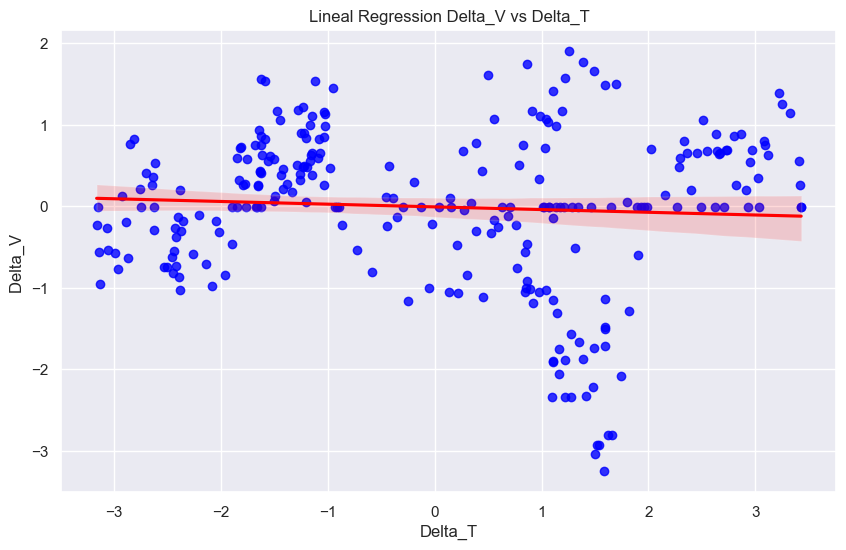

In [429]:
sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))
p=sns.regplot(x='dT', y='ln_IoIm2', data=df_merged, scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel('Delta_T')
plt.ylabel('Delta_V ')
plt.title('Lineal Regression Delta_V vs Delta_T')
slope, intercept, r, p, sterr = scipy.stats.linregress(x=p.get_lines()[0].get_xdata(),
                                                       y=p.get_lines()[0].get_ydata())

#plt.text(2, 95, 'y = ' + str(round(intercept,3)) + ' + ' + str(round(slope,3)) + 'x')
plt.show()